<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Assignment_Day_8_Adnan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Assignment Day 8
Nama: Adnan  
Dataset: Dataset Dummy Buat Sendiri (100 responden)  


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load dataset
df = pd.read_excel("/content/drive/My Drive/dibimbing/Tugas/Assignment Day 8 Adnan/dataset_dummy.xlsx")

# Tampilkan 5 baris pertama (transposed agar mudah dibaca)
df.head().T

,0,1,2,3,4
No,1,2,3,4,5
Nama,"Yosef Wahyuni, S.H.",Pangeran Iswahyudi,Tina Wijaya,Yulia Pangestu,Legawa Agustina
Email,winarnosaka@example.com,qsalahudin@example.net,mahendraviman@example.net,danuja56@example.net,galuhhassanah@example.com
No Telepon,0857854849,+62 (96) 527 9543,(030) 543-0264,+62 (020) 065 8625,088 583 7304
Nama Lokasi,Mall X,Mall Y,Kampus B,Warnet Maju,Co-Work Hub
Tipe Lokasi,Public,Public,Campus,Coworking,Coworking
Jam Login,7,8,17,7,7
Tahun Lahir,2000,1981,1987,1986,2003
Usia,24,43,37,38,21
Merk HP,Xiaomi,Realme,Oppo,Nokia,Realme


In [7]:
# Cek nama kolom
df.columns.tolist()

['No',
 'Nama',
 'Email',
 'No Telepon',
 'Nama Lokasi',
 'Tipe Lokasi',
 'Jam Login',
 'Tahun Lahir',
 'Usia',
 'Merk HP',
 'Jenis Kelamin',
 'Status',
 'Minat Digital (1-10)',
 'Frekuensi Login/Minggu',
 'Durasi Login (menit)',
 'Pengeluaran Digital/Bulan (Rp)',
 'Rata-rata Durasi per Sesi (menit)',
 'Tingkat Ketergantungan Digital (1-5)']

In [8]:
# Cek tipe data dan info umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   No                                    100 non-null    int64  
 1   Nama                                  100 non-null    object 
 2   Email                                 100 non-null    object 
 3   No Telepon                            100 non-null    object 
 4   Nama Lokasi                           100 non-null    object 
 5   Tipe Lokasi                           100 non-null    object 
 6   Jam Login                             100 non-null    int64  
 7   Tahun Lahir                           100 non-null    int64  
 8   Usia                                  100 non-null    int64  
 9   Merk HP                               100 non-null    object 
 10  Jenis Kelamin                         100 non-null    object 
 11  Status              

In [9]:
# Cek missing values
print("Missing Values per Kolom:")
print(df.isnull().sum())

Missing Values per Kolom:
No                                      0
Nama                                    0
Email                                   0
No Telepon                              0
Nama Lokasi                             0
Tipe Lokasi                             0
Jam Login                               0
Tahun Lahir                             0
Usia                                    0
Merk HP                                 0
Jenis Kelamin                           0
Status                                  0
Minat Digital (1-10)                    0
Frekuensi Login/Minggu                  0
Durasi Login (menit)                    0
Pengeluaran Digital/Bulan (Rp)          0
Rata-rata Durasi per Sesi (menit)       0
Tingkat Ketergantungan Digital (1-5)    0
dtype: int64



## 1. Eksplorasi Data & Statistik Deskriptif

Menghitung **mean, median, mode, variance, standar deviasi, dan range** untuk semua variabel numerik utama.

In [10]:
# Definisikan kolom numerik yang akan dianalisis
numeric_cols = [
    "Usia",
    "Minat Digital (1-10)",
    "Frekuensi Login/Minggu",
    "Durasi Login (menit)",
    "Pengeluaran Digital/Bulan (Rp)",
    "Jam Login"
]

df_num = df[numeric_cols]

In [11]:
# Hitung statistik deskriptif
stats = pd.DataFrame({
    "Mean"    : df_num.mean(),
    "Median"  : df_num.median(),
    "Mode"    : df_num.mode().iloc[0],
    "Variance": df_num.var(),
    "Std_Dev" : df_num.std(),
    "Min"     : df_num.min(),
    "Max"     : df_num.max(),
})

# Tambahkan kolom Range
stats["Range"] = stats["Max"] - stats["Min"]

# Tampilkan hasil dibulatkan 2 desimal
stats.round(2)

,Mean,Median,Mode,Variance,Std_Dev,Min,Max,Range
Usia,28.09,27.0,23.0,8.362000e+01,9.14,14,44,30
Minat Digital (1-10),5.70,6.0,7.0,7.260000e+00,2.69,1,10,9
Frekuensi Login/Minggu,7.07,7.0,1.0,1.720000e+01,4.15,1,14,13
Durasi Login (menit),128.34,130.5,76.0,4.630370e+03,68.05,15,240,225
Pengeluaran Digital/Bulan (Rp),1532392.38,1468112.0,102398.0,7.032694e+11,838611.57,102398,2996625,2894227
Jam Login,13.51,13.0,12.0,1.967000e+01,4.43,6,22,16


### Interpretasi Statistik Deskriptif

#### 1. Usia
- Rata-rata usia responden adalah 28,09 tahun, menunjukkan bahwa mayoritas pengguna berada di kategori usia muda (dewasa awal).
- Median 27 tahun dan modus 23 tahun mengkonfirmasi distribusi yang sedikit right-skewed — ada responden yang lebih tua (maks. 44 tahun) yang menarik rata-rata ke atas.
- Range 30 tahun (14–44 tahun) menunjukkan keberagaman usia yang cukup lebar dalam dataset ini.
- Standar deviasi 9,14 berarti data usia cukup bervariasi atau tersebar, tidak terpusat pada satu kelompok umur saja.

#### 2. Minat Digital (1–10)
- Rata-rata minat digital 5,70 menunjukkan responden memiliki minat digital yang sedang–tinggi.
- Modus 7 dan median 6 menunjukkan banyak responden cenderung antusias terhadap aktivitas digital.
- Standar deviasi 2,69 cukup besar relatif terhadap skalanya (1–10), artinya persebaran minat digital antar responden cukup lebar — ada yang sangat tidak minat (nilai 1) hingga sangat minat (nilai 10).

#### 3. Frekuensi Login/Minggu
- Rata-rata 7,07 kali login per minggu (hampir setiap hari), menandakan penggunaan digital yang rutin.
- Modus 1 dan median 7 menunjukkan adanya dua kelompok: pengguna sangat jarang dan pengguna sangat aktif.
- Range 13 (1–14) menunjukkan variasi yang ekstrem — ada yang hanya login sekali seminggu, ada yang login setiap hari bahkan dua kali sehari.

#### 4. Durasi Login (menit)
- Rata-rata durasi 128,34 menit (sekitar 2 jam lebih) per sesi menunjukkan intensitas penggunaan yang cukup tinggi.
- Standar deviasi 68,05 menit yang sangat besar menandakan ada responden yang sangat singkat (15 menit) dan ada yang sangat lama (240 menit).

#### 5. Pengeluaran Digital/Bulan (Rp)
- Rata-rata Rp 1.532.392 per bulan, yang cukup signifikan dan menunjukkan keterlibatan ekonomi digital yang nyata.
- Standar deviasi Rp 838.611 yang tinggi menunjukkan kesenjangan besar antar responden — dari Rp 102.398 hingga Rp 2.996.625.

#### 6. Jam Login
- Rata-rata jam login 13,51 (siang menuju sore) dengan modus 12 menunjukkan pengguna paling banyak login di siang hari.
- Range 16 jam (jam 6 pagi – jam 22 malam) menunjukkan aktivitas digital berlangsung sepanjang hari.


## 2. Analisis Hubungan Variabel (Covariance & Correlation)

In [12]:
# --- Usia vs Minat Digital ---
cov_usia_minat  = df["Usia"].cov(df["Minat Digital (1-10)"])
corr_usia_minat = df["Usia"].corr(df["Minat Digital (1-10)"])

# --- Pengeluaran Digital vs Frekuensi Login ---
cov_spend_freq  = df["Pengeluaran Digital/Bulan (Rp)"].cov(df["Frekuensi Login/Minggu"])
corr_spend_freq = df["Pengeluaran Digital/Bulan (Rp)"].corr(df["Frekuensi Login/Minggu"])

# --- Minat Digital vs Durasi Login ---
cov_minat_durasi  = df["Minat Digital (1-10)"].cov(df["Durasi Login (menit)"])
corr_minat_durasi = df["Minat Digital (1-10)"].corr(df["Durasi Login (menit)"])

In [13]:
print("=" * 45)
print("  HASIL COVARIANCE & CORRELATION")
print("=" * 45)

print("\n1. Usia vs Minat Digital")
print(f"   Covariance  : {round(cov_usia_minat, 4)}")
print(f"   Correlation : {round(corr_usia_minat, 4)}")

print("\n2. Pengeluaran Digital vs Frekuensi Login")
print(f"   Covariance  : {round(cov_spend_freq, 2)}")
print(f"   Correlation : {round(corr_spend_freq, 4)}")

print("\n3. Minat Digital vs Durasi Login")
print(f"   Covariance  : {round(cov_minat_durasi, 4)}")
print(f"   Correlation : {round(corr_minat_durasi, 4)}")

  HASIL COVARIANCE & CORRELATION

1. Usia vs Minat Digital
   Covariance  : -0.2354
   Correlation : -0.0096

2. Pengeluaran Digital vs Frekuensi Login
   Covariance  : 131226.48
   Correlation : 0.0377

3. Minat Digital vs Durasi Login
   Covariance  : -12.6343
   Correlation : -0.0689


###  Interpretasi Covariance & Correlation

| Pasangan Variabel | Covariance | Correlation | Arah | Kekuatan |
|---|---|---|---|---|
| Usia vs Minat Digital | -0.2354 | -0.0096 | Negatif | Sangat Lemah |
| Pengeluaran vs Frekuensi Login | 131,226.48 | 0.0377 | Positif | Sangat Lemah |
| Minat Digital vs Durasi Login | -12.6343 | -0.0689 | Negatif | Sangat Lemah |

Penjelasan:

1. Usia vs Minat Digital (r = -0.0096):  
   Korelasi sangat mendekati nol, artinya hampir tidak ada hubungan linear antara usia dengan minat digital. Orang yang lebih tua tidak selalu kurang berminat pada aktivitas digital di dataset ini.

2. Pengeluaran Digital vs Frekuensi Login (r = 0.0377):  
   Korelasi positif tetapi sangat lemah. Artinya, frekuensi login yang lebih sering tidak secara signifikan berkaitan dengan pengeluaran digital yang lebih besar. Pengeluaran mungkin lebih dipengaruhi faktor lain (jenis platform, kebutuhan spesifik, dll.).

3. Minat Digital vs Durasi Login (r = -0.0689):
   Korelasi negatif sangat lemah. Secara mengejutkan, orang yang lebih berminat digital tidak otomatis login lebih lama. Ini bisa berarti responden dengan minat tinggi lebih efisien dalam penggunaan waktu digitalnya.


## 3. Expected Value & Confidence Interval

In [14]:
# === Expected Value: Minat Digital ===
expected_value_minat = df["Minat Digital (1-10)"].mean()
print(f"Expected Value (Nilai Harapan) Minat Digital: {expected_value_minat:.4f}")

Expected Value (Nilai Harapan) Minat Digital: 5.7000


In [15]:
# === Confidence Interval 95% untuk Mean Minat Digital ===
mean_minat = df["Minat Digital (1-10)"].mean()
std_minat  = df["Minat Digital (1-10)"].std()
n          = df["Minat Digital (1-10)"].count()

z             = 1.96  # Z-score untuk 95% confidence
margin_error  = z * (std_minat / np.sqrt(n))

lower_ci = mean_minat - margin_error
upper_ci = mean_minat + margin_error

print("=" * 50)
print("  CONFIDENCE INTERVAL — Minat Digital (95%)")
print("=" * 50)
print(f"  Mean          : {mean_minat:.4f}")
print(f"  Std Deviation : {std_minat:.4f}")
print(f"  n (sampel)    : {n}")
print(f"  Margin Error  : ±{margin_error:.4f}")
print(f"  CI 95%        : ({lower_ci:.4f} , {upper_ci:.4f})")
print("=" * 50)

  CONFIDENCE INTERVAL — Minat Digital (95%)
  Mean          : 5.7000
  Std Deviation : 2.6949
  n (sampel)    : 100
  Margin Error  : ±0.5282
  CI 95%        : (5.1718 , 6.2282)


### Interpretasi Expected Value & Confidence Interval

Expected Value (Nilai Harapan) Minat Digital = 5.70  
Artinya, jika kita mengambil satu responden secara acak dari populasi ini, nilai minat digital yang paling kita "harapkan" atau perkirakan adalah 5.70 dari skala 1–10. Ini mencerminkan tingkat minat digital yang sedang-tinggi secara rata-rata di populasi.

Confidence Interval 95%: (5.1718, 6.2282)
Dengan tingkat kepercayaan 95%, rata-rata minat digital populasi yang sebenarnya diperkirakan berada di antara 5.17 hingga 6.23. Artinya:
- Kita cukup yakin bahwa rata-rata populasi tidak jatuh di bawah 5 (tidak rendah).
- Interval yang relatif sempit ini (lebar ≈ 1.06) menunjukkan estimasi yang cukup presisi, karena didukung 100 sampel.
- Jika penelitian diulang 100 kali dengan sampel berbeda, 95 di antaranya akan menghasilkan interval yang mencakup nilai rata-rata populasi yang sebenarnya.


## 4. Segmentasi & Visualisasi

### 4.1 Rata-rata Minat Digital berdasarkan Jenis Kelamin

In [16]:
mean_minat_gender = (
    df.groupby("Jenis Kelamin")["Minat Digital (1-10)"]
      .mean()
      .reset_index()
      .rename(columns={"Minat Digital (1-10)": "Rata-rata Minat Digital"})
)
print(mean_minat_gender.to_string(index=False))

Jenis Kelamin  Rata-rata Minat Digital
    Laki-laki                 5.361702
    Perempuan                 6.000000


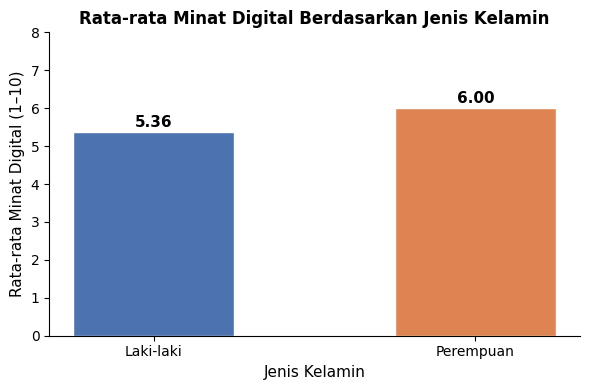

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(
    mean_minat_gender["Jenis Kelamin"],
    mean_minat_gender["Rata-rata Minat Digital"],
    color=colors, edgecolor="white", width=0.5
)
# Label nilai di atas bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
ax.set_ylim(0, 8)
ax.set_xlabel("Jenis Kelamin", fontsize=11)
ax.set_ylabel("Rata-rata Minat Digital (1–10)", fontsize=11)
ax.set_title("Rata-rata Minat Digital Berdasarkan Jenis Kelamin", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.2 Rata-rata Pengeluaran Digital berdasarkan Status

In [18]:
mean_pengeluaran = (
    df.groupby("Status")["Pengeluaran Digital/Bulan (Rp)"]
      .mean()
      .reset_index()
      .rename(columns={"Pengeluaran Digital/Bulan (Rp)": "Rata-rata Pengeluaran"})
)
print(mean_pengeluaran.to_string(index=False))

   Status  Rata-rata Pengeluaran
  Lainnya           1.597261e+06
Mahasiswa           1.429320e+06
  Pekerja           1.544044e+06


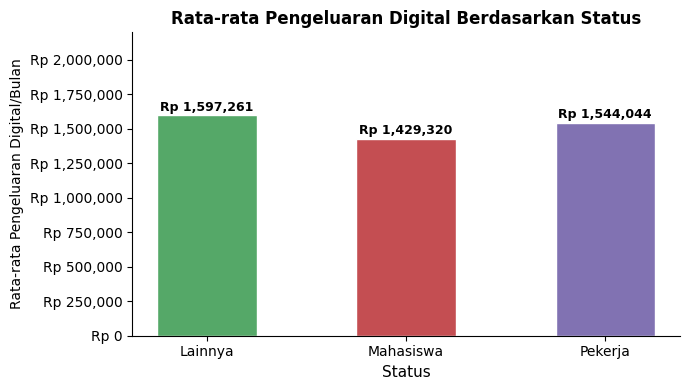

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
colors2 = ["#55A868", "#C44E52", "#8172B2"]
bars2 = ax.bar(
    mean_pengeluaran["Status"],
    mean_pengeluaran["Rata-rata Pengeluaran"],
    color=colors2, edgecolor="white", width=0.5
)
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f"Rp {bar.get_height():,.0f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
ax.set_ylim(0, 2_200_000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:,.0f}"))
ax.set_xlabel("Status", fontsize=11)
ax.set_ylabel("Rata-rata Pengeluaran Digital/Bulan", fontsize=10)
ax.set_title("Rata-rata Pengeluaran Digital Berdasarkan Status", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.3 Rata-rata Durasi Login berdasarkan Tipe Lokasi

In [20]:
mean_durasi_lokasi = (
    df.groupby("Tipe Lokasi")["Durasi Login (menit)"]
      .mean()
      .reset_index()
      .rename(columns={"Durasi Login (menit)": "Rata-rata Durasi (menit)"})
)
print(mean_durasi_lokasi.to_string(index=False))

Tipe Lokasi  Rata-rata Durasi (menit)
     Campus                152.538462
  Coworking                110.826087
    Private                114.560000
     Public                132.884615


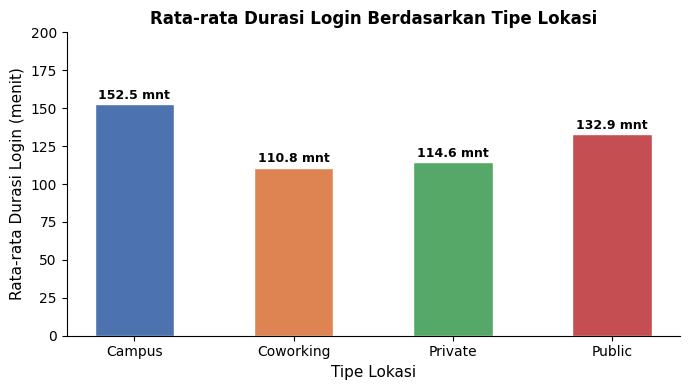

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
colors3 = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars3 = ax.bar(
    mean_durasi_lokasi["Tipe Lokasi"],
    mean_durasi_lokasi["Rata-rata Durasi (menit)"],
    color=colors3, edgecolor="white", width=0.5
)
for bar in bars3:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{bar.get_height():.1f} mnt",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
ax.set_ylim(0, 200)
ax.set_xlabel("Tipe Lokasi", fontsize=11)
ax.set_ylabel("Rata-rata Durasi Login (menit)", fontsize=11)
ax.set_title("Rata-rata Durasi Login Berdasarkan Tipe Lokasi", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.4 Distribusi Usia (Histogram)

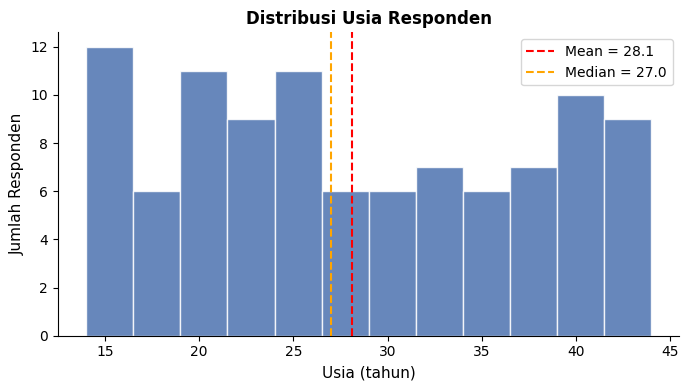

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Usia"], bins=12, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(df["Usia"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean = {df['Usia'].mean():.1f}")
ax.axvline(df["Usia"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median = {df['Usia'].median():.1f}")
ax.set_xlabel("Usia (tahun)", fontsize=11)
ax.set_ylabel("Jumlah Responden", fontsize=11)
ax.set_title("Distribusi Usia Responden", fontsize=12, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.5 Boxplot: Pengeluaran Digital berdasarkan Jenis Kelamin

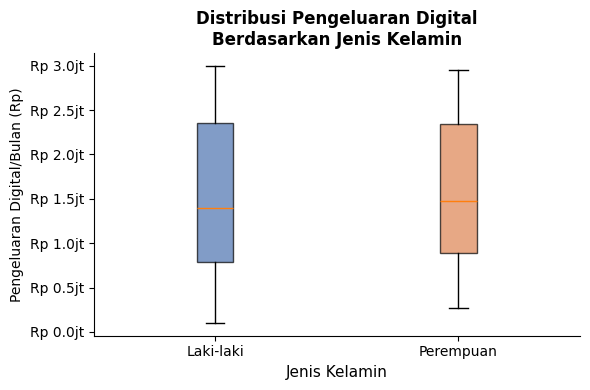

In [23]:
groups = [group["Pengeluaran Digital/Bulan (Rp)"].values
          for _, group in df.groupby("Jenis Kelamin")]
labels_box = df["Jenis Kelamin"].unique().tolist()
labels_box.sort()

fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(groups, labels=labels_box, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x/1e6:.1f}jt"))
ax.set_xlabel("Jenis Kelamin", fontsize=11)
ax.set_ylabel("Pengeluaran Digital/Bulan (Rp)", fontsize=10)
ax.set_title("Distribusi Pengeluaran Digital\nBerdasarkan Jenis Kelamin", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.6 Scatter Plot: Usia vs Pengeluaran Digital

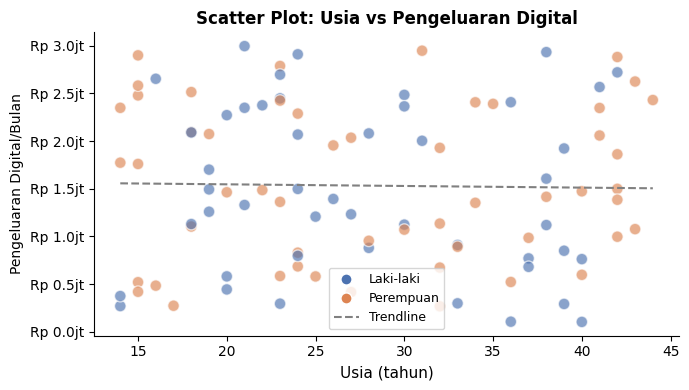

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
colors_gender = df["Jenis Kelamin"].map({"Laki-laki": "#4C72B0", "Perempuan": "#DD8452"})
ax.scatter(df["Usia"], df["Pengeluaran Digital/Bulan (Rp)"],
           c=colors_gender, alpha=0.65, edgecolors="white", s=70)

# Trend line
z = np.polyfit(df["Usia"], df["Pengeluaran Digital/Bulan (Rp)"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["Usia"].min(), df["Usia"].max(), 100)
ax.plot(x_line, p(x_line), "--", color="gray", linewidth=1.5, label="Trend")

# Legend manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='Laki-laki'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DD8452', markersize=8, label='Perempuan'),
    Line2D([0], [0], linestyle='--', color='gray', label='Trendline')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x/1e6:.1f}jt"))
ax.set_xlabel("Usia (tahun)", fontsize=11)
ax.set_ylabel("Pengeluaran Digital/Bulan", fontsize=10)
ax.set_title("Scatter Plot: Usia vs Pengeluaran Digital", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5. Insight & Kesimpulan

### Insight Utama dari Analisis

#### A. Profil Demografis & Perilaku Digital
- Dataset didominasi oleh responden muda dengan rata-rata usia 28 tahun, mencerminkan populasi yang akrab dengan teknologi digital.
- Pengguna rata-rata login **7 kali per minggu** selama 128 menit per sesi — ini menunjukkan keterlibatan digital yang cukup intensif dan rutin.
- Pengeluaran digital rata-rata Rp 1.532.392/bulan merupakan angka yang signifikan, mengindikasikan bahwa aktivitas digital telah menjadi bagian integral dari kehidupan ekonomi responden.

#### B. Perbedaan Berdasarkan Segmentasi
- Perempuan (6.00) memiliki rata-rata minat digital sedikit lebih tinggi** dibandingkan laki-laki (5.36), meskipun perbedaannya tidak drastis.
- Dari sisi pengeluaran berdasarkan status: kelompok Lainnya (Rp 1.597.261) mengeluarkan paling banyak, diikuti Pekerja (Rp 1.544.044) dan Mahasiswa (Rp 1.429.320). Selisih tidak terlalu jauh, namun menunjukkan Mahasiswa lebih hemat secara digital.
- Lokasi Campus memiliki rata-rata durasi login tertinggi (152,54 menit), diikuti Public (132,88 mnt). Pengguna di lokasi Campus cenderung login lebih lama, kemungkinan karena ketersediaan WiFi yang stabil dan aktivitas akademik yang mendukung.

#### C. Hubungan Antar Variabel
- Semua pasangan variabel yang dianalisis menunjukkan korelasi yang sangat lemah (mendekati nol). Ini berarti tidak ada hubungan linear yang kuat antara usia, minat digital, frekuensi login, durasi login, maupun pengeluaran digital satu sama lain.
- Temuan ini penting: frekuensi login tinggi tidak menjamin pengeluaran besar, dan minat digital tinggi tidak berarti durasi login lebih panjang.

---

### Kesimpulan

1. Karakteristik utama populasi: Pengguna digital dalam dataset ini adalah individu muda (rata-rata 28 tahun) dengan tingkat keterlibatan digital yang sedang-tinggi, baik dari sisi frekuensi, durasi, maupun pengeluaran.

2. Variabilitas data tinggi: Hampir semua variabel numerik memiliki standar deviasi yang cukup besar, mengindikasikan keberagaman perilaku digital yang signifikan di antara responden - tidak ada pola yang seragam.

3. Hubungan antar variabel tidak linear: Tidak ada dua variabel yang memiliki korelasi kuat. Ini menunjukkan bahwa perilaku digital dipengaruhi oleh kombinasi faktor kompleks yang tidak bisa dijelaskan hanya dengan satu variabel saja.

4. Segmentasi memberikan insight lebih kaya: Perbedaan berdasarkan jenis kelamin, status, dan tipe lokasi menunjukkan pola yang lebih informatif dibandingkan analisis keseluruhan - segmentasi adalah kunci untuk memahami perilaku digital secara lebih spesifik.

5. Expected Value Minat Digital = 5.70 dengan CI 95% (5.17-6.23) menunjukkan bahwa secara statistik, populasi ini memiliki minat digital yang cenderung di atas rata-rata skala (lebih dari nilai tengah 5), dan estimasi ini cukup presisi dengan 100 sampel.